# Objectif 


L'objectif est de justifier l'hypothèse d'existence d'une sous variété de l'espace des RTFs. Pour se faire, on cherche à mimer les résultats présentés par Gannot dans les différentes présentations (EUSIPCO 2019 / Co Colloquium 2020).

## Cadre de l'étude 

* Antenne HLA de deux capteurs, immersion fixe $z_a = 50$ m.
* Source d'immersion fixe $z_s = 5$ m, distance au capteur de référence r variable. 
* Environnement : guide d'onde idéal (fond parfaitement solide), profondeur $D_w = 100$ m. 

## Approche 

L'immersion de la source est fixée à $z_s = 5$ m, la distance $r$ de la source au capteur de référence (capteur 1) varie dans un intervalle $I_r$, 

$$ I_r = [r_{ref} - \Delta_r, r_{ref} + \Delta_r] $$ 

** Définition du RTF 
$$
    \mathbf{\Pi_{12}} \overset{\Delta}{=}
    \left [ \frac{H_{2}(k_1)}{H_{1}(k_1)}, \, \frac{H_{2}(k_2)}{H_{1}(k_2)} \, ..., \, \frac{H_{2}(k_D)}{H_{1}(k_D)} \right]^T \in \mathbb{C}^D
$$

On s'intéresse à la distance entre le RTF $\mathbf{\Pi_{12}}(r)$ associé à la position $r$ de la source et le RTF de référence $\mathbf{\Pi_{12}}^{ref} = \mathbf{\Pi_{12}}({r = r_{ref}})$ associé associé à la position de référence $r_{ref}$. 

Pour illustrer la structure de variété des données, on considère plusieurs mesures de distance : 

* Distance Euclidienne (hypothèse d'un espace euclidien) 

$$ d_{Euc}(r) = \lVert \Pi_{12}(r) - \Pi_{12}^{ref} \rVert $$ 

* Angle hermitien moyen (mesure d'angle canonique dans $\mathbb{C}^D$)

$$ \theta(r) = \frac{\lvert \Pi_{12}(r) {\Pi_{12}^{ref}}^H \rvert}{\lVert \Pi_{12}(r) \rVert \lVert \Pi_{12}^{ref} \rVert} $$ 

* Distance après projection ISOMAP (méthode d'apprentissage de la structure nonlinéaire de la variété)

* Distance CPA (hypothèses ? )

* Distance de diffusion 

$$ d_{Diff}(r) \approx \lVert \Phi_d(\Pi_{12}(r)) - \Phi_d(\Pi_{12}^{ref}) \rVert $$


## Rappel formulation modale 

On pose 
$$
    Q =  \frac{e^{i3\pi/4}}{\rho(z_s) \sqrt{8 \pi}}
$$

et

$$
    A_m(z) = \Psi_m(z_{s}) \Psi_m(z) \frac{1}{\sqrt{k_{rm}}}
$$

La fonction de transfert du guide d'onde s'écrit,

$$
    H(f, r, z) = \frac{Q}{\sqrt{r}} \sum_{m=1}^{\infty} A_m(z) e^{-ik_{rm}
    r}
$$

En particulier, la fonction de transfert du canal de propagation associée au récepteur $j$ est :

$$
    H_{j} = \frac{Q}{\sqrt{r_j}} \sum_{m=1}**{\infty} A_m(z_j) e^{-ik_{rm}
    r_{j}}
$$

on s'intéresse au vecteur de RTF défini par

$$
    \mathbf{\Pi} \overset{\Delta}{=}
    \left [ \frac{H_{1}}{H_{1}} \, \frac{H_{2}}{H_{1}} \, \dots \, \frac{H_{M}}{H_{1}} \right ]^T
    = \frac{1}{H_{1}} \mathbf{H}
$$

En particulier, il s'agira d'étudier le comportement d'une composante du vecteur $\mathbf{\Pi}$,

$$
    \Pi_j = \frac{H_j}{H_1}, \quad j \in [1, J]
$$

**Conditions aux limites (cas parfaitement solide -> perfectly_rigid) **

Pression nulle en surface et au fond :
$$
p(r, z=0) = 0 \quad \text{et} \quad \frac{\partial p(r, z)}{\partial z} \rvert_{z=D} = 0 
$$

et les fonctions modales s'écrivent 

$$
\Psi_m(z) = \sqrt{\frac{2 \rho}{D}} \sin(k_{zm} z)
$$

Les fonctions $\Psi_m$ sont les fonctions propres associées aux valeurs propres $k_{rm}$,

$$
    k_{rm} = \sqrt{ k^2 - k_{zm}^2}
$$

avec, 

$$ 
k_{zm} =  (m - \frac{1}{2}) \frac{\pi}{D}, \quad m \in \mathbb{N}^{*} .
$$           

In [1]:
# %matplotlib ipympl

import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from propa.ideal_waveguide import (
    kr,
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    intensity,
    intensity_1,
)


import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure, color

In [2]:
# Define usefull paths 
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")
img_dir = os.path.join(current_dir, "img")
if not os.path.exists(img_dir):
    os.makedirs(img_dir)
    print(f"Created directory: {img_dir}")

Current directory: c:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration\general_ocean_acoustics\modal_theory\rtf_modal_theory


# Etape 1 : définition du guide d'onde et génération du jeu de données 

### Paramètres de la simulation

In [3]:
# Waveguide
# bottom_bc = 'pressure_release' # Bottom boundary condition
bottom_bc = "perfectly_rigid"  # Bottom boundary condition
Dw = 100 # Depth of the waveguide

# Receiver
d12 = 10
z_a = 50 # Depth of receiver

# Source
r_ref = 50 * 1e3 # Reference range in meters
z_s = 5 # Depth of source 

# Define range vectors
nrgrid = 2001
delta_r = 2.5 * 1e3
rmin = r_ref - delta_r
rmax = r_ref + delta_r
r_grid = np.linspace(rmin, rmax, nrgrid)
r_grid_km = r_grid / 1e3
r_grid1 = r_grid    # Range from source to receiver 1
r_grid2 = r_grid + d12  # Range from source to receiver 2

In [4]:
# Frequency vector
fmin = 10  # Minimum frequency in Hz
fmax = 20  # Maximum frequency in Hz
# fs = 100
# Ts = 1 / fs
# Tw = 5
# nw = Tw * fs
# Df = nw // 2
# print(Df)
Df = 100  # Number of frequency samples
f = np.linspace(fmin, fmax, Df) # Frequency vector

In [5]:
abcd_labels = ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l"]

## Représentation de quelques fonctions de transfert 

In [6]:
ff, rr, zz, p_field1 = field(
        f=f,
        z_src=z_a,    # Reciprocity: source is at antenna depth
        z=z_s,           # Reciprocity: receiver is at source depth
        r=r_grid1,
        depth=Dw,
        bottom_bc=bottom_bc,
    )
ff, _, _, p_field2 = field(
    f=f,
    z_src=z_a,    # Reciprocity: source is at antenna depth
    z=z_s,           # Reciprocity: receiver is at source depth
    r=r_grid2,                                    
    depth=Dw,
    bottom_bc=bottom_bc,
)
p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20

p_field1 = p_field1.squeeze()
p_field2 = p_field2.squeeze()

In [7]:
n_propagating_modes_fmin = nb_propagating_modes(
    f=fmin, c=g.c0, depth=Dw, bottom_bc=bottom_bc
)
print(f"Number of propagating modes at fmin = {fmin} Hz : {n_propagating_modes_fmin}")
n_propagating_modes_fmax = nb_propagating_modes(
    f=fmax, c=g.c0, depth=Dw, bottom_bc=bottom_bc
)
print(f"Number of propagating modes at fmax = {fmax} Hz : {n_propagating_modes_fmax}")

Number of propagating modes at fmin = 10 Hz : 1
Number of propagating modes at fmax = 20 Hz : 3


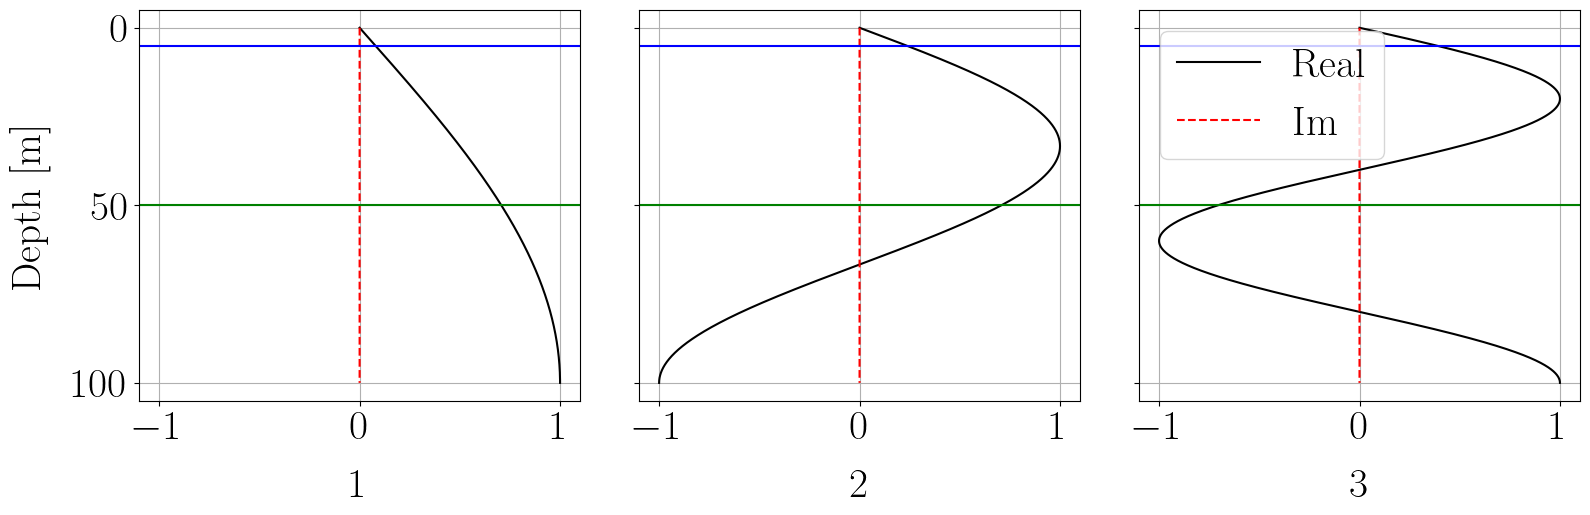

In [8]:
# Derive first three modes
M = n_propagating_modes_fmax

modes = np.arange(1, M + 1).astype(int)
modal_fcts = []
z = np.linspace(0, Dw, int(1e4))  # Depths vector for modal functions
for m in modes:

    # psi_m = psi_normalised(m=m, z=z, depth=D, rho=g.rho_w, bottom_bc=bottom_bc)
    psi_m = psi(m=m, z=z, depth=Dw, bottom_bc=bottom_bc)

    # Cast to complex to match with the general form of the modal function
    psi_m = psi_m.astype(complex)
    modal_fcts.append(psi_m)

modal_fcts = np.array(modal_fcts)

# Plot modal functions
lfig = LargeFigure()

fig, axs = plt.subplots(1, len(modes), sharey=True)
# Revert y-axis
axs[0].invert_yaxis()

max_amp = np.max(np.abs(modal_fcts))
axs[0].set_ylabel("Depth [m]")

for i, m in enumerate(modes):
    axs[i].plot(np.real(modal_fcts[i]), z, label=f"Real", linestyle="-", color="k")
    axs[i].plot(np.imag(modal_fcts[i]), z, label=f"Im", linestyle="--", color="r")
    axs[i].set_xlabel(m)
    axs[i].set_xlim([-1.1 * max_amp, 1.1 * max_amp])
    axs[i].grid()

    # Add lines at source and receiver depths
    axs[i].axhline(z_s, color="blue", linestyle="-", label="Source depth" if i == 0 else "")
    axs[i].axhline(z_a, color="green", linestyle="-", label="Receiver depth" if i == 0 else "")

plt.legend()

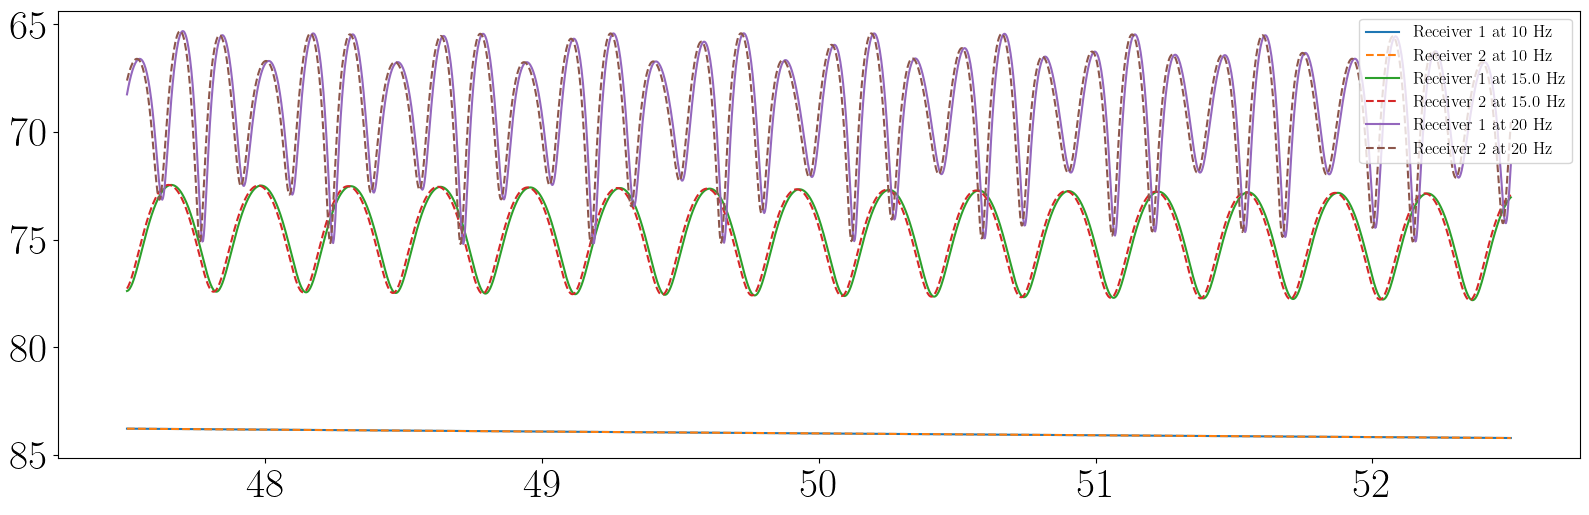

In [9]:
# Plot TL at fmin, fmax and center frequency
lfig = LargeFigure(legend_fontsize=12)
frequencies_to_plot = [fmin, (fmin + fmax) / 2, fmax]
for freq in frequencies_to_plot:
    idx_freq = np.argmin(np.abs(f - freq))

    tl1 = -20 * np.log10(4 * np.pi * np.abs(p_field1[idx_freq, :]) + 1e-20)
    tl2 = -20 * np.log10(4 * np.pi * np.abs(p_field2[idx_freq, :]) + 1e-20)

    plt.plot(r_grid / 1e3, tl1, label=f"Receiver 1 at {freq} Hz", linestyle="-")
    plt.plot(r_grid / 1e3, tl2, label=f"Receiver 2 at {freq} Hz", linestyle="--")
plt.legend()
plt.gca().invert_yaxis()

In [10]:
# Compute the dataset
def calc_pi_12(f, r_grid1, r_grid2, z_source, z_antenna, depth, bottom_bc):

    ff, rr, zz, p_field1 = field(
        f=f,
        z_src=z_antenna,    # Reciprocity: source is at antenna depth
        z=z_source,           # Reciprocity: receiver is at source depth
        r=r_grid1,
        depth=depth,
        bottom_bc=bottom_bc,
    )
    ff, _, _, p_field2 = field(
        f=f,
        z_src=z_antenna,    # Reciprocity: source is at antenna depth
        z=z_source,           # Reciprocity: receiver is at source depth
        r=r_grid2,                                    
        depth=depth,
        bottom_bc=bottom_bc,
    )
    p_field2[(p_field2 == 0) | np.isnan(p_field2)] = 1e-20
    p_field1[(p_field1 == 0) | np.isnan(p_field1)] = 1e-20
    pi_12 = p_field2 / p_field1

    return ff, rr, zz, pi_12

In [11]:
# Compute RTF on the whole grid for a different number of modes
ff, rr, zz, pi_12 = calc_pi_12(
    f=f,
    r_grid1=r_grid1,
    r_grid2=r_grid2,
    z_source=z_s,
    z_antenna=z_a,
    depth=Dw,
    bottom_bc=bottom_bc,
)

# Compute RTF at reference range
ff, rr_ref, zz, pi_12_ref = calc_pi_12(
    f=f,
    r_grid1=np.array([r_ref]),
    r_grid2=np.array([r_ref + d12]),
    z_source=z_s,
    z_antenna=z_a,
    depth=Dw,
    bottom_bc=bottom_bc,
)

print("Dataset computed")

Dataset computed


In [12]:
ds = xr.Dataset(
    data_vars=dict(
        data=(["f", "r"], pi_12.squeeze(axis=1)),
        data_ref=(["f"], pi_12_ref.squeeze(axis=(1, 2))),
    ),
    coords=dict(
        f=f,
        r=rr.squeeze(),
    ),
    attrs=dict(
        description=f"RTF dataset for an ideal waveguide. The antenna is composed of two receivers separated by d12={d12}m. The source is at z_s={z_s}m and the antenna at z_a={z_a}m in a waveguide of depth Dw={Dw}m.",
        bottom_bc=bottom_bc,
        Dw=Dw,
        z_s=z_s,
        z_a=z_a,
        r_ref=r_ref,
        d12=d12,
    ),
)

In [13]:
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:   (f: 100, r: 2001)
Coordinates:
  * f         (f) float64 800B 10.0 10.1 10.2 10.3 10.4 ... 19.7 19.8 19.9 20.0
  * r         (r) float64 16kB 4.75e+04 4.75e+04 4.75e+04 ... 5.25e+04 5.25e+04
Data variables:
    data      (f, r) complex64 2MB (0.9254524-0.37858608j) ... (1.2142978-0.3...
    data_ref  (f) complex64 800B (0.9254573-0.37858805j) ... (1.1084371-0.310...
Attributes:
    description:  RTF dataset for an ideal waveguide. The antenna is composed...
    bottom_bc:    perfectly_rigid
    Dw:           100
    z_s:          5
    z_a:          50
    r_ref:        50000.0
    d12:          10


In [14]:
# Cuttof freq for mode 2
omegac2 = (2 - 1/2) * np.pi * g.c0 / Dw
print(f"Cutoff frequency for mode 2: {omegac2/(2*np.pi)} Hz")

Cutoff frequency for mode 2: 11.25 Hz


In [15]:
# plt.figure()
# plt.plot(ds.f, 20*np.log10(np.abs(ds.data_ref)), label="[dB]")

# plt.figure()
# rtf_mod_fr = 20 * np.log10(np.abs((ds.data)))
# rtf_mod_fr.plot(cmap="jet")

# # Same things for the phase
# plt.figure()
# plt.plot(ds.f, np.angle(ds.data_ref), label="[rad]")

# plt.figure()
# rtf_phase_fr = np.angle((ds.data))
# plt.pcolormesh(ds.r, ds.f, rtf_phase_fr, shading="auto", cmap="jet")
# plt.axhline(y=11.15, color="k", linestyle="-")
# plt.colorbar(label="Phase [rad]")

In [16]:
# plt.figure()
# plt.scatter(np.real(ds.data), np.imag(ds.data), c=ds.r, cmap="jet")
# # plt.xlim(0, np.max(np.real(ds.data)) * 1.2)
# # plt.ylim(0, np.max(np.imag(ds.data)) * 1.2)
# plt.colorbar(label="Range (m)")
# plt.xlabel("Real part of RTF")
# plt.ylabel("Imaginary part of RTF")
# plt.title("RTF in complex plane colored by range")

# # Add quiver to show the vector of the ref 
# plt.quiver(0, 0, np.real(ds.data_ref), np.imag(ds.data_ref), angles='xy', scale_units='xy', scale=1, color='green', label='RTF at reference range', zorder=2)
# # Add quiver of two other RTF points
# plt.quiver(0, 0, np.real(ds.data.isel(r=0)), np.imag(ds.data.isel(r=0)), angles='xy', scale_units='xy', scale=1, color='blue', label='RTF at min range', zorder=3)
# plt.quiver(0, 0, np.real(ds.data.isel(r=-1)), np.imag(ds.data.isel(r=-1)), angles='xy', scale_units='xy', scale=1, color='red', label='RTF at max range', zorder=1)

# # Zoom in around the reference RTF
# # plt.xlim(np.real(ds.data_ref) * 0.9986, np.real(ds.data_ref) * 1.0014)
# # plt.ylim(np.imag(ds.data_ref) * 0.9986, np.imag(ds.data_ref) * 1.0014)

## Calcul de l'ensemble des distances 

### Distance Euclidienne 

In [17]:
d_Euc = np.linalg.norm((ds.data - ds.data_ref.values[:, np.newaxis]), axis=0)

(49.9, 50.1)

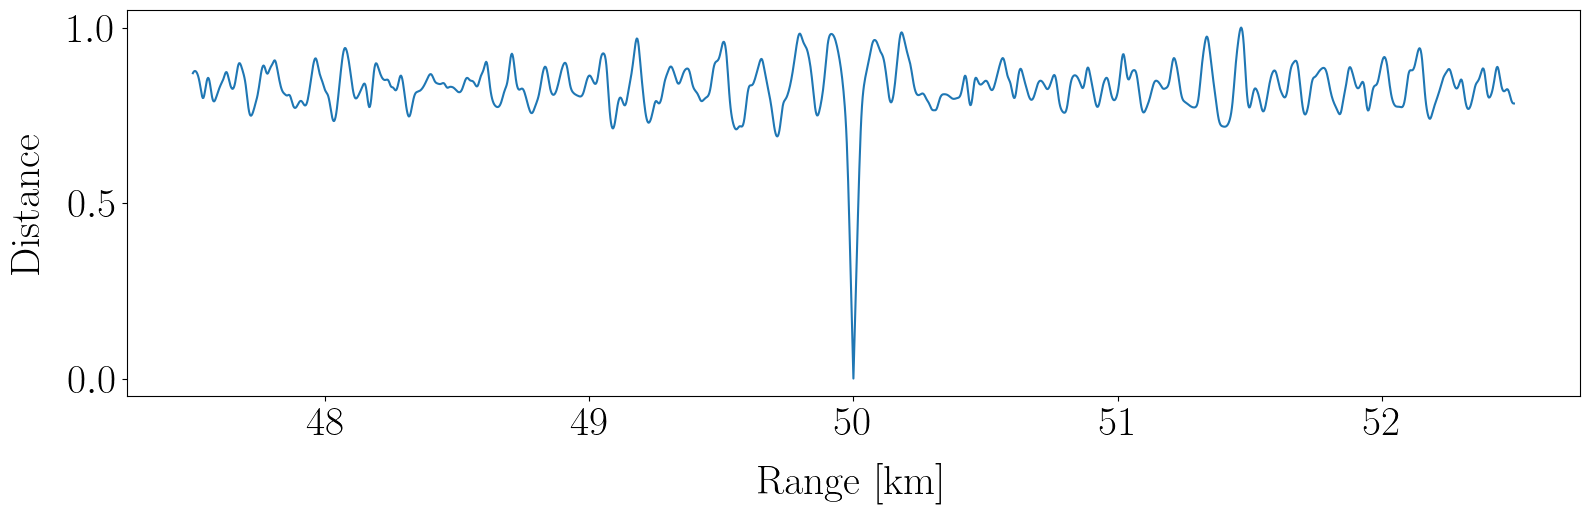

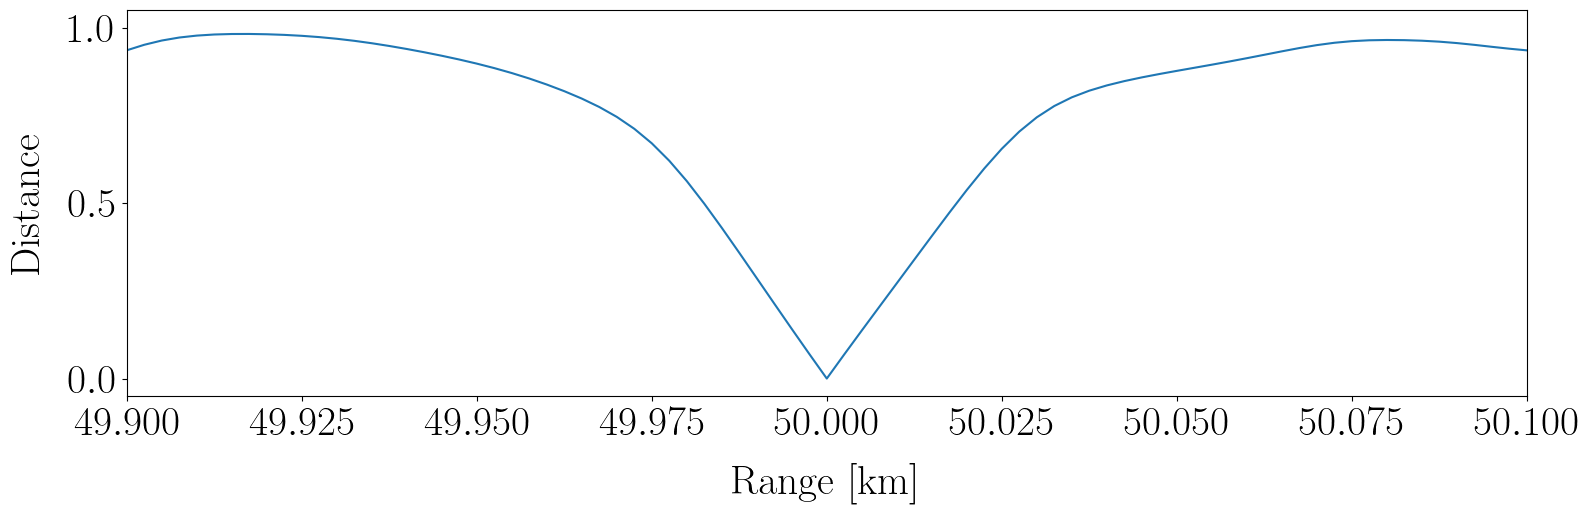

In [18]:
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc))
plt.xlabel("Range [km]")
plt.ylabel("Distance")

plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc))
plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)

### Angle hermitien

In [19]:
inner_prod = np.abs(np.sum(ds.data_ref.values[:, np.newaxis].conj() * ds.data, axis=0))
norm_ref = np.linalg.norm(ds.data_ref, axis=0)
norm_rtf = np.linalg.norm(ds.data, axis=0)
# Cosine of Hermitian angle, clipped for stability
cos_angle = np.clip(inner_prod / (norm_ref * norm_rtf), -1.0, 1.0)
d_hermitien = np.arccos(cos_angle)

# Convert to degrees
d_hermitien_deg = np.rad2deg(d_hermitien)

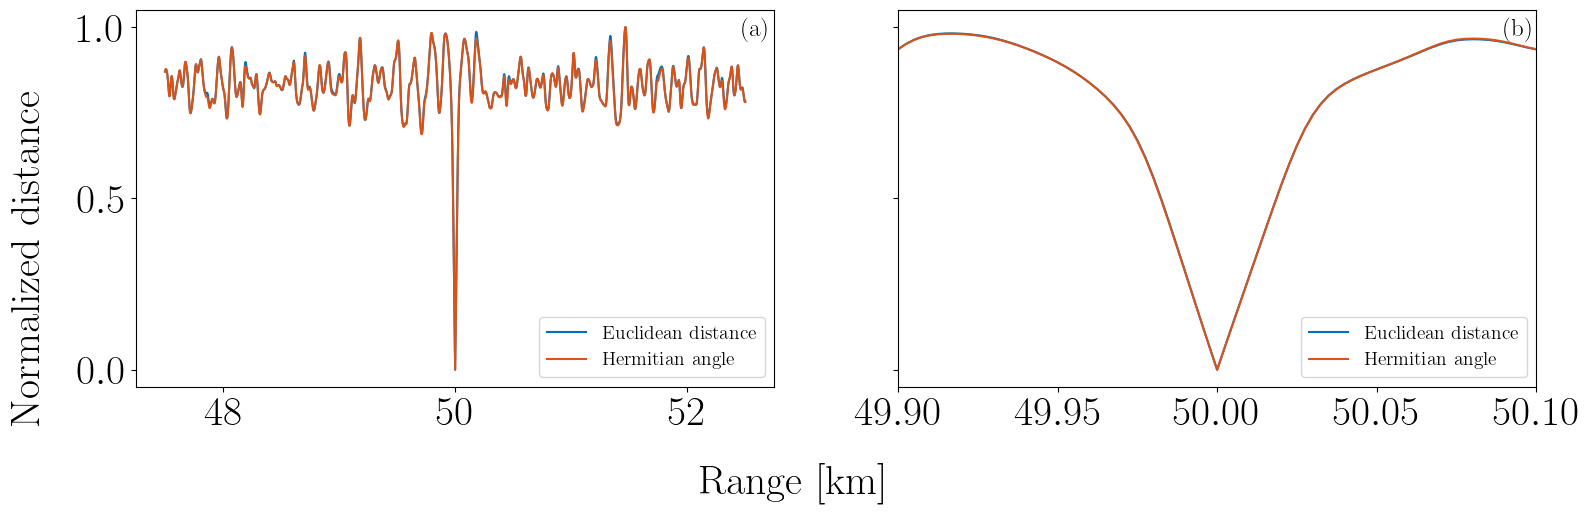

In [20]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(r_grid_km, d_hermitien / np.max(d_hermitien),  color=color(1), label="Hermitian angle")

ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    d_hermitien / np.max(d_hermitien),
    color=color(1),
    label="Hermitian angle",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_hermitian_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

### Commentaires distance euclidienne et hermitienne

Les distances euclidienne et hermitienne présentent des résultats analogues. 

Proche du point de référence la distance est monotone, traduisant ainsi la structure localement euclidienne de l'espace des données. En revanche, lorsque l'on s'éloigne de quelques centaines de mètres du point de référence, la distance  n'est plus monotone et oscille autour d'un palier. 

Ces deux distances ne sont donc pas appropriée pour mesurer la proximité (en range seulement ici) de la source au point de référence. 

### Distance PCA

Les données sont linéairement projetées sur les composantes principales du jeu de données. La projection étant linéaire, la variété est donc supposée "linéaire / plate".  

La librairie sklearn ne propose pas d'implémentation de la PCA pour des données complexes. Pour palier ce problème on implémente la PCA à la main avec l'algo de SVD. 


* Remarque : 

On peut vérifier que notre algorithme converge vers la même solution que l'implémentation sklearn. Dans le cas du jeu de données étudié ici il faut toutefois forcer le mode de calcul de sklearn (svd_solver="full") afin d'éviter que l'algorithme ne bascule automatiquement sur l'algorithme randomized SVD (Halko et al.). 

In [21]:
def pca_svd(X, k):
    # 1. Centrage
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # 2. SVD
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    # 3. Directions principales
    W = Vt[:k].T

    # 4. Projection
    X_pca = X_centered @ W

    return X_pca, W, S, mean

#### Rapide de test pour vérifier que les deux solutions sont identiques 

In [22]:
# d = 1
# X = ds.data.real.T.values
# X = X[:300, :1000]  # Reduce size for faster computation
# X_pca_manual, W_manual, S_manual, mean_manual = pca_svd(X, k=d)

# from sklearn.decomposition import PCA

# pca = PCA(n_components=d, svd_solver="full")
# X_pca_sklearn = pca.fit_transform(X)

In [23]:
# print("Axes PCA (manuel) :\n", W_manual)
# print("Axes PCA (sklearn) :\n", pca.components_.T)
# print("Projection manuelle :\n", X_pca_manual)
# print("Projection sklearn :\n", X_pca_sklearn)
# np.allclose(X_pca_manual, X_pca_sklearn)
# np.allclose(X_pca_manual, -X_pca_sklearn)

# n = X.shape[0]
# explained_variance_manual = (S_manual**2) / (n - 1)
# ratio_manual = explained_variance_manual / np.sum(explained_variance_manual)

# print("Variance expliquée sklearn :", pca.explained_variance_)
# print("Variance expliquée manuelle :", explained_variance_manual[:d])
# print("Ratio variance expliquée sklearn :", pca.explained_variance_ratio_)
# print("Ratio variance expliquée manuelle :", ratio_manual[:d])
# np.allclose(explained_variance_manual[:d], pca.explained_variance_);

# # Correction éventuelle du signe
# sign = np.sign(np.sum(X_pca_manual * X_pca_sklearn, axis=0))
# X_pca_manual_aligned = X_pca_manual * sign

# np.allclose(X_pca_manual_aligned, X_pca_sklearn)

In [24]:
# # Check that both solutions are the same
# plt.figure()
# plt.plot(X_pca_manual_aligned, label="PCA manual")
# plt.plot(X_pca_sklearn, label="PCA sklearn", linestyle="--")
# plt.legend()

#### Calcul PCA et distance associée 

##### Avec d = 1 composante 

In [25]:
d = 1
X = ds.data.values
X_ref = ds.data_ref.values
X_augmented = np.concatenate((X, X_ref[:, np.newaxis]), axis=1).T

X_pca_, W, S, mean = pca_svd(X_augmented, k=d)

In [26]:
X_pca = X_pca_[:-1, :].T
X_pca_ref = X_pca_[-1:, :].T

(0.0, 100.0)

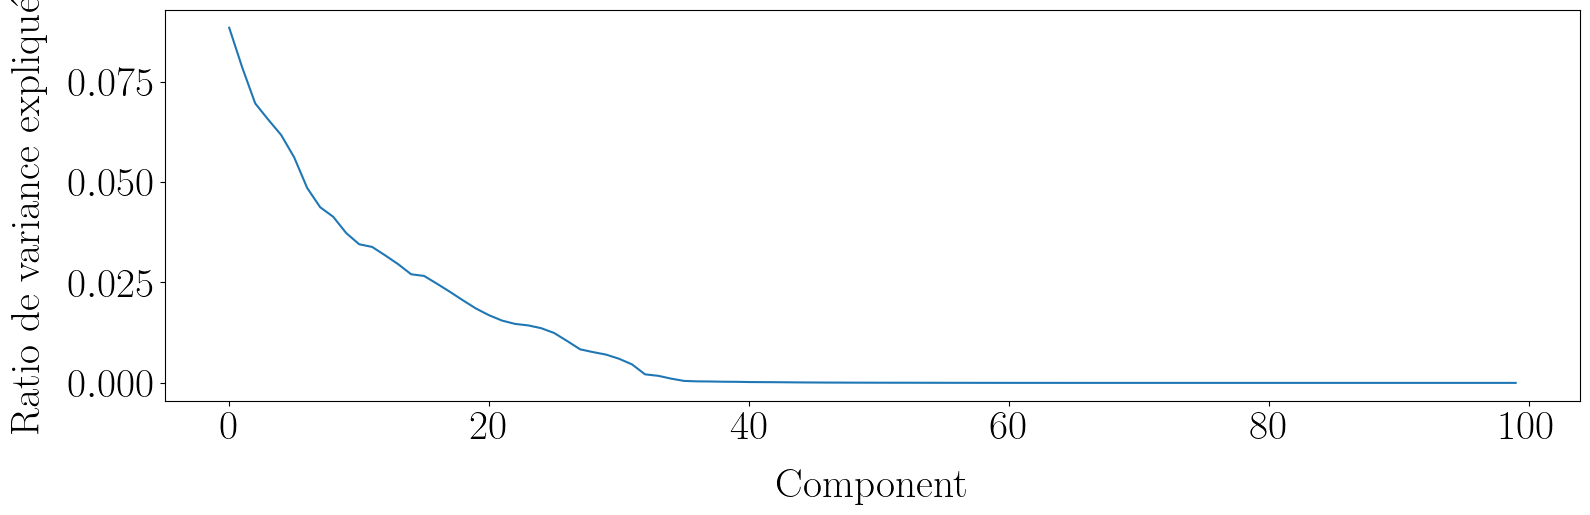

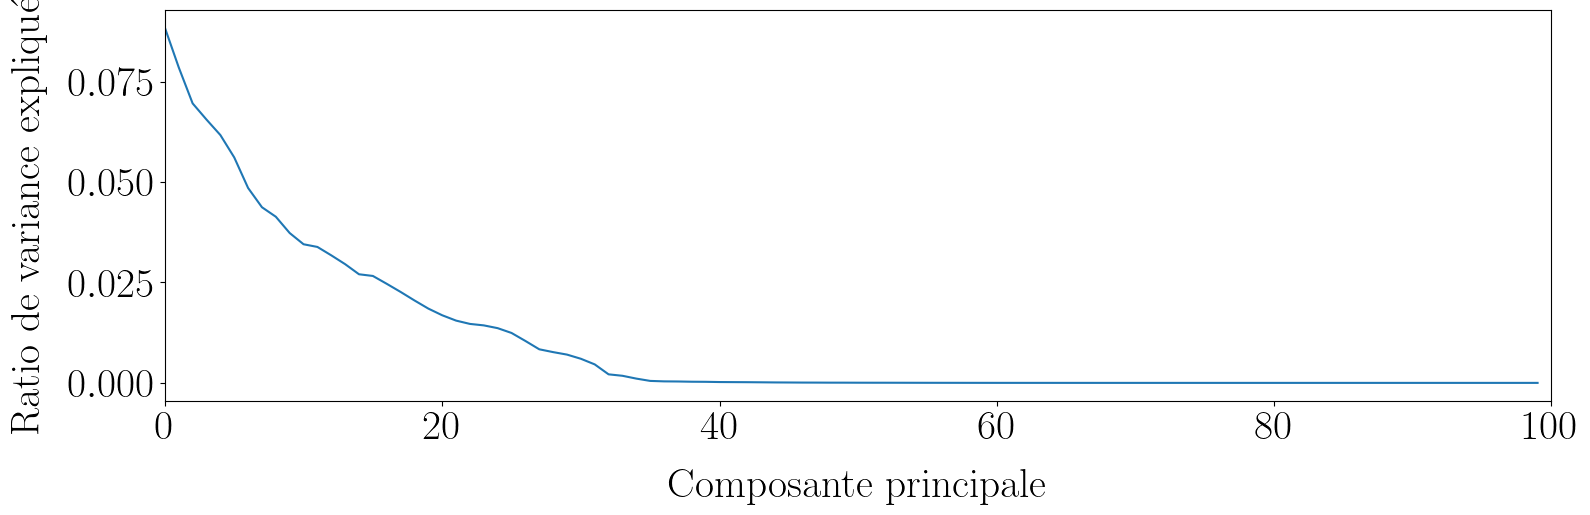

In [27]:
# Calcul du ratio de la variance expliquée par chaque composante
n = X_augmented.shape[0]
explained_variance_manual = (S**2) / (n - 1)
ratio_manual = explained_variance_manual / np.sum(explained_variance_manual)

plt.figure()
plt.plot(ratio_manual)
plt.xlabel("Component")
plt.ylabel("Ratio de variance expliquée")

plt.figure()
plt.plot(ratio_manual)
plt.xlabel("Composante principale")
plt.ylabel("Ratio de variance expliquée")
plt.xlim(0, 100)

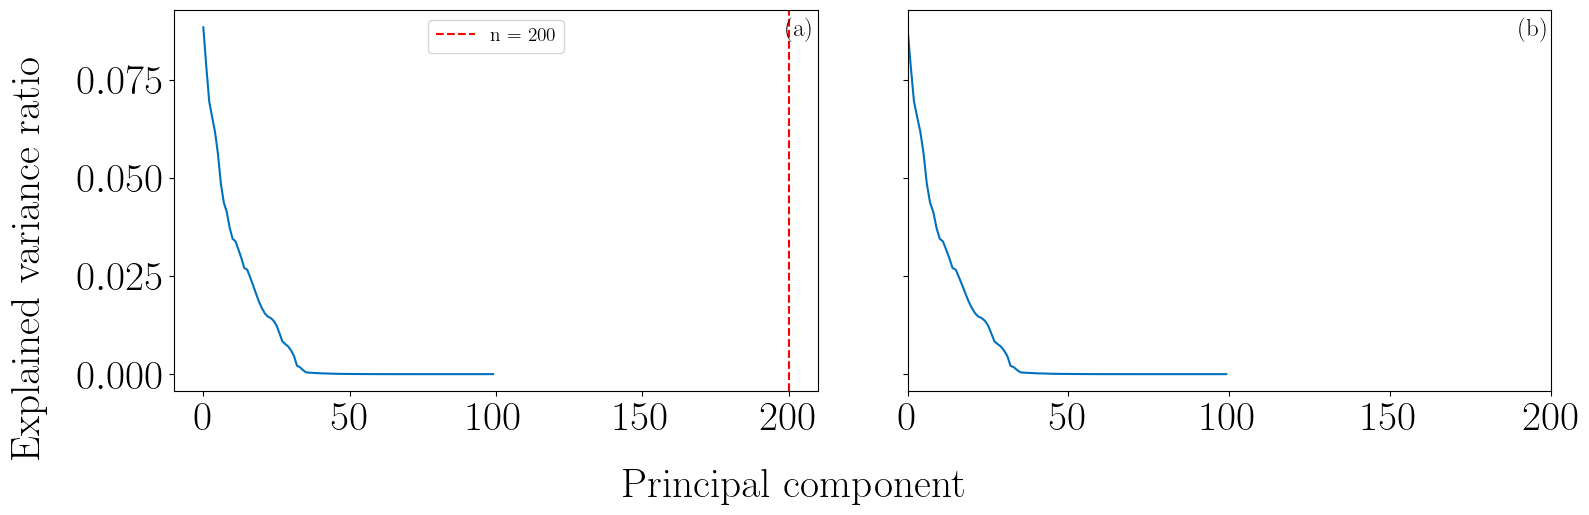

In [28]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs

ax1.plot(ratio_manual, color=color(0))
ax1.axvline(200, color="r", linestyle="--", label="n = 200")
ax1.legend()
ax2.plot(ratio_manual, color=color(0))
ax2.set_xlim(0, 200)

fig.supxlabel("Principal component")
fig.supylabel("Explained variance ratio")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"pca_{d}comp_ratio_var_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

Text(0, 0.5, '$ \\phi(e_1) $')

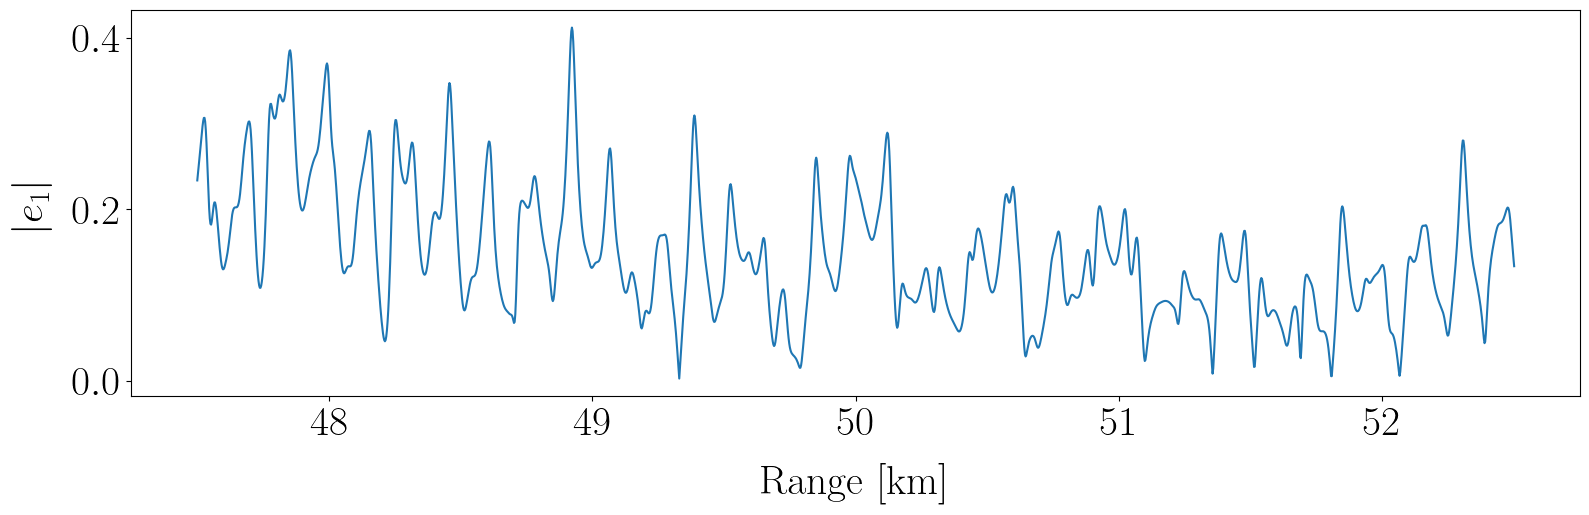

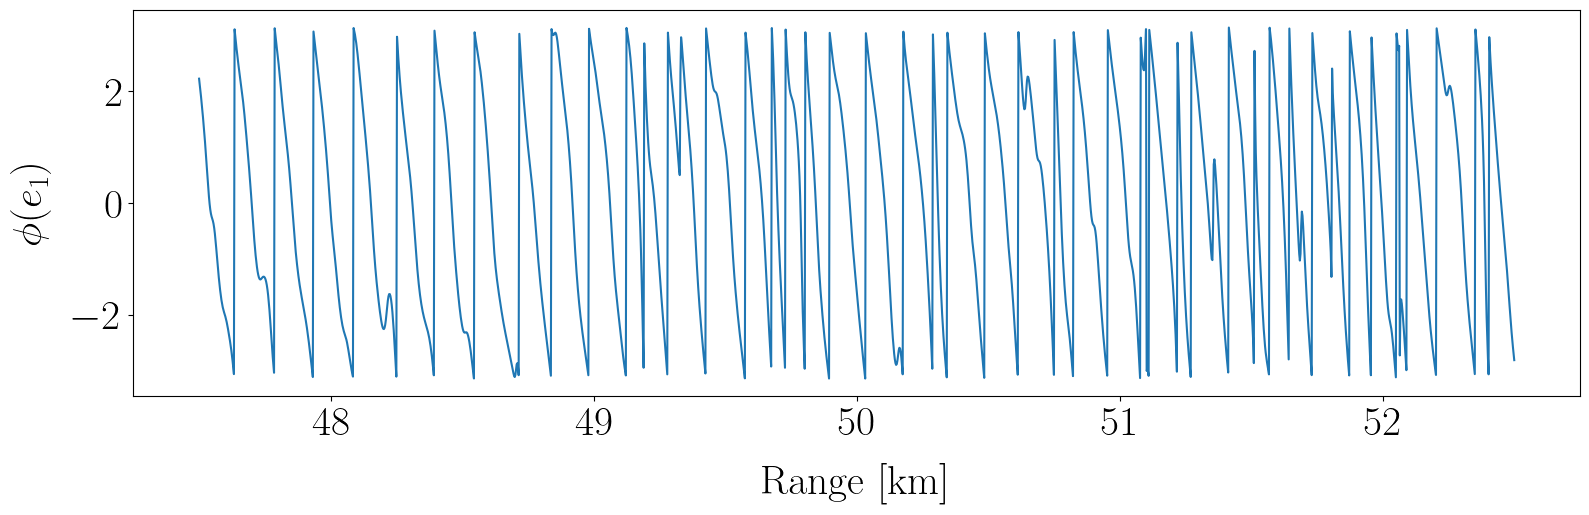

In [29]:
# Plot transform data
plt.figure()
plt.plot(r_grid_km, np.abs(X_pca)[0, :], label="PCA")
plt.xlabel("Range [km]")
plt.ylabel(r"$\lvert e_1 \rvert $")

plt.figure()
plt.plot(r_grid_km, np.angle(X_pca)[0, :], label="PCA")
plt.xlabel("Range [km]")
plt.ylabel(r"$ \phi(e_1) $")

In [30]:
d_PCA = np.linalg.norm(X_pca - X_pca_ref, axis=0)

(49.9, 50.1)

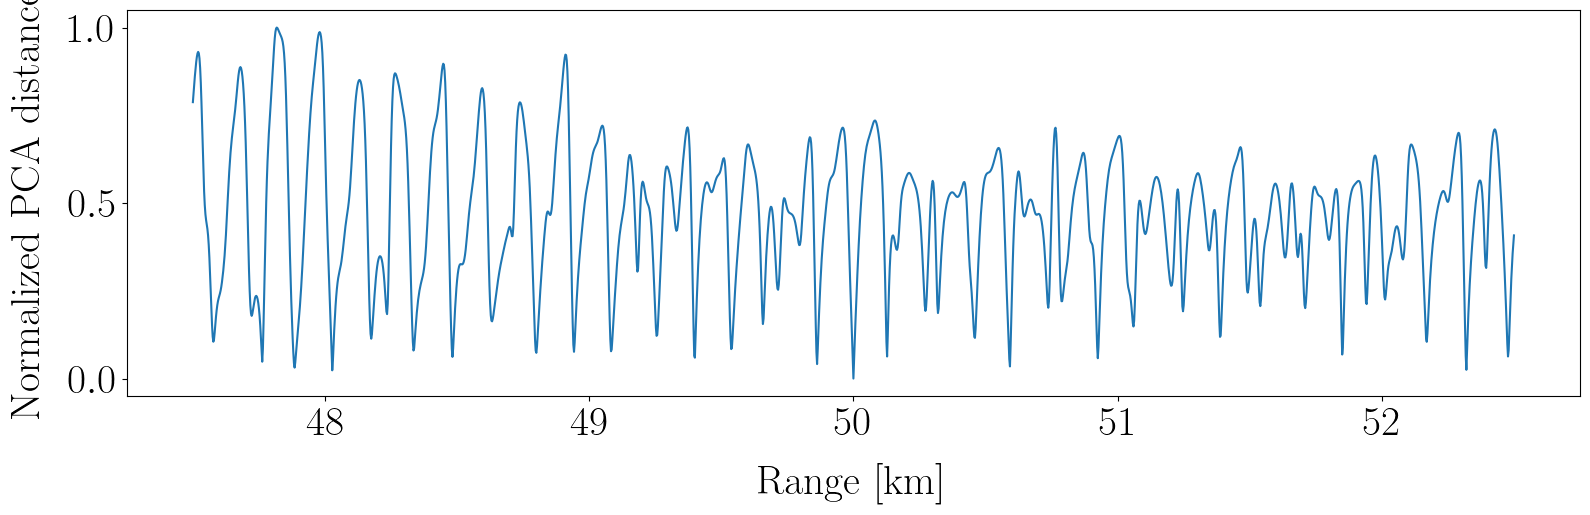

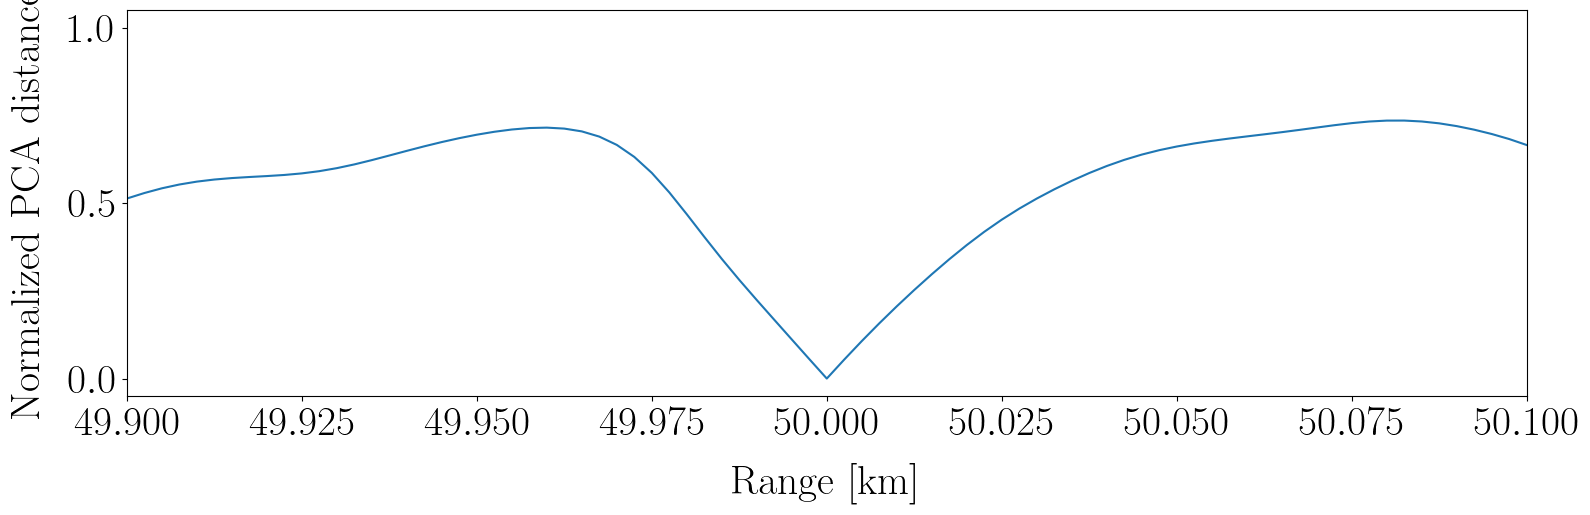

In [31]:
plt.figure()
plt.plot(r_grid_km, d_PCA / np.max(d_PCA))
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")

plt.figure()
plt.plot(r_grid_km, d_PCA / np.max(d_PCA))
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)

##### Commentaires 

Une unique composante (correspondant au seul degré de liberté du problème) ne permet pas de représenter de manière satisfaisante le jeu de données. 

Le ratio de variance expliquée est important pour les 20 à 30 premières composantes. Ainsi, l'analyse en composante principale ne permet pas de réduire la dimensionnalité de l'espace des données au nombre d = 1 de degré de liberté du problème. 

In [32]:
ncomp = 200
X_pca_, W, S, mean = pca_svd(X_augmented, k=ncomp)

X_pca = X_pca_[:-1, :].T
X_pca_ref = X_pca_[-1:, :].T

d_PCA_ncomp = np.linalg.norm(X_pca - X_pca_ref, axis=0)

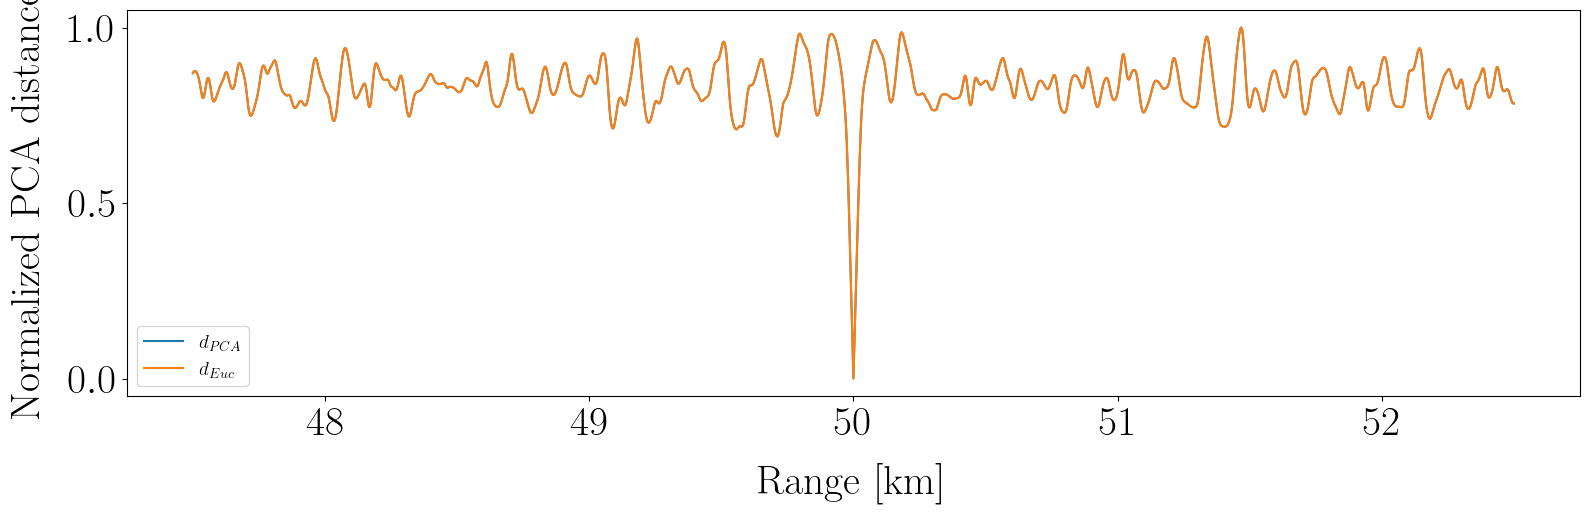

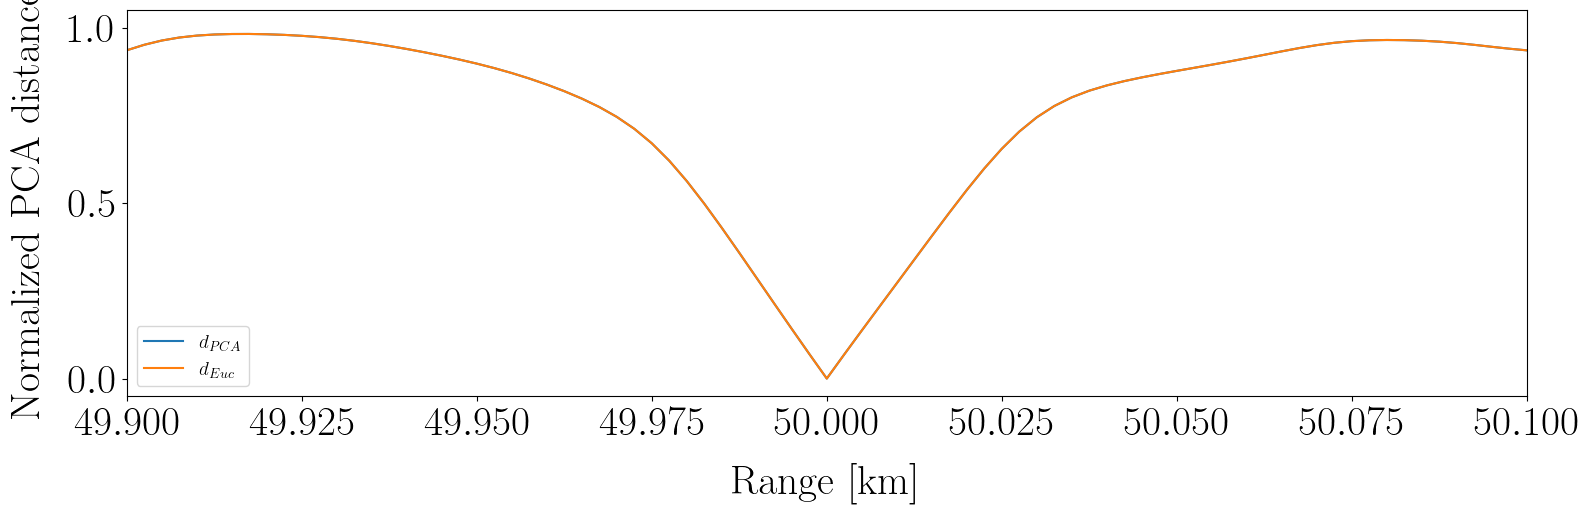

In [33]:
plt.figure()
plt.plot(r_grid_km, d_PCA_ncomp / np.max(d_PCA_ncomp), label=r"$d_{PCA}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.legend()

plt.figure()
plt.plot(r_grid_km, d_PCA_ncomp / np.max(d_PCA_ncomp), label=r"$d_{PCA}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Normalized PCA distance")
plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
plt.legend()

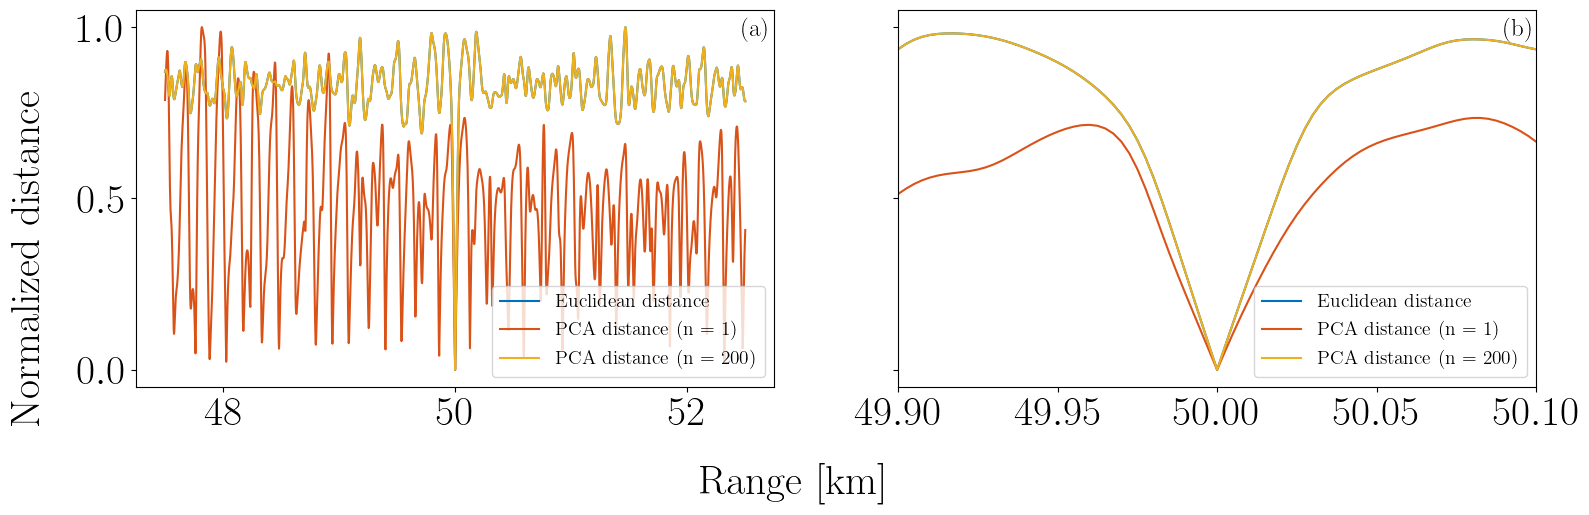

In [34]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(
    r_grid_km,
    d_PCA / np.max(d_PCA),
    color=color(1),
    label=f"PCA distance (n = {d})",
)
ax1.plot(
    r_grid_km,
    d_PCA_ncomp / np.max(d_PCA_ncomp),
    color=color(2),
    label=f"PCA distance (n = {ncomp})",
)
ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    d_PCA / np.max(d_PCA),
    color=color(1),
    label=f"PCA distance (n = {d})",
)
ax2.plot(
    r_grid_km,
    d_PCA_ncomp / np.max(d_PCA_ncomp),
    color=color(2),
    label=f"PCA distance (n = {ncomp})",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_pca_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

##### Commentaires 

Dans le cas où l'on augmente le nombre de composantes à k = 30, la projection dans le nouvel espace engendre une faible perte d'information et on retrouve une évolution de la distance proche de celle observée pour la distance euclidienne. 

Le domaine de linéarité de la distance ainsi calculée reste faible. 

### Distance ISOMAP

Une troisième approche consiste à utiliser des méthodes de réduction de dimension non linéaire. 

Il s'agit ainsi de définir une projection non linéaire et de mesurer la distance entre deux éléments du dataset par la distance euclidienne dans l'espace de projection. La distance calculée représente la distance géodésique (i.e le long de l'espace courbe d'origine). 

In [35]:
from sklearn.manifold import Isomap
emb = Isomap(n_neighbors=5, n_components=d)

X = ds.data.values
X_ref = ds.data_ref.values
X_augmented = np.concatenate((X, X_ref[:, np.newaxis]), axis=1).T

# # Partie réelle
# X_augmented_re = X_augmented.real 
# X_isomap_re = emb.fit_transform(X=X_augmented_re)
# # Partie imaginaire
# X_augmented_im = X_augmented.imag
# X_isomap_im = emb.fit_transform(X=X_augmented_im)
# Module
X_augmented_mod = np.abs(X_augmented)
X_isomap_mod = emb.fit_transform(X=X_augmented_mod)
# Phase
X_augmented_phase = np.angle(X_augmented)
X_isomap_phase = emb.fit_transform(X=X_augmented_phase)

X_isomap_dict = {
    # "real": {"X_isomap": X_isomap_re},
    # "imag": {"X_isomap": X_isomap_im},
    "mod": {"X_isomap": X_isomap_mod},
    "phase": {"X_isomap": X_isomap_phase},
}

In [36]:
# Compute each distance
for key in X_isomap_dict.keys():
    X_isomap = X_isomap_dict[key]["X_isomap"]
    X_isomap_data = X_isomap[:-1, :].T
    X_isomap_ref = X_isomap[-1:, :].T
    d_isomap = np.linalg.norm(X_isomap_data - X_isomap_ref, axis=0)

    # Att to dictionnary
    X_isomap_dict[key]["d_isomap"] = d_isomap

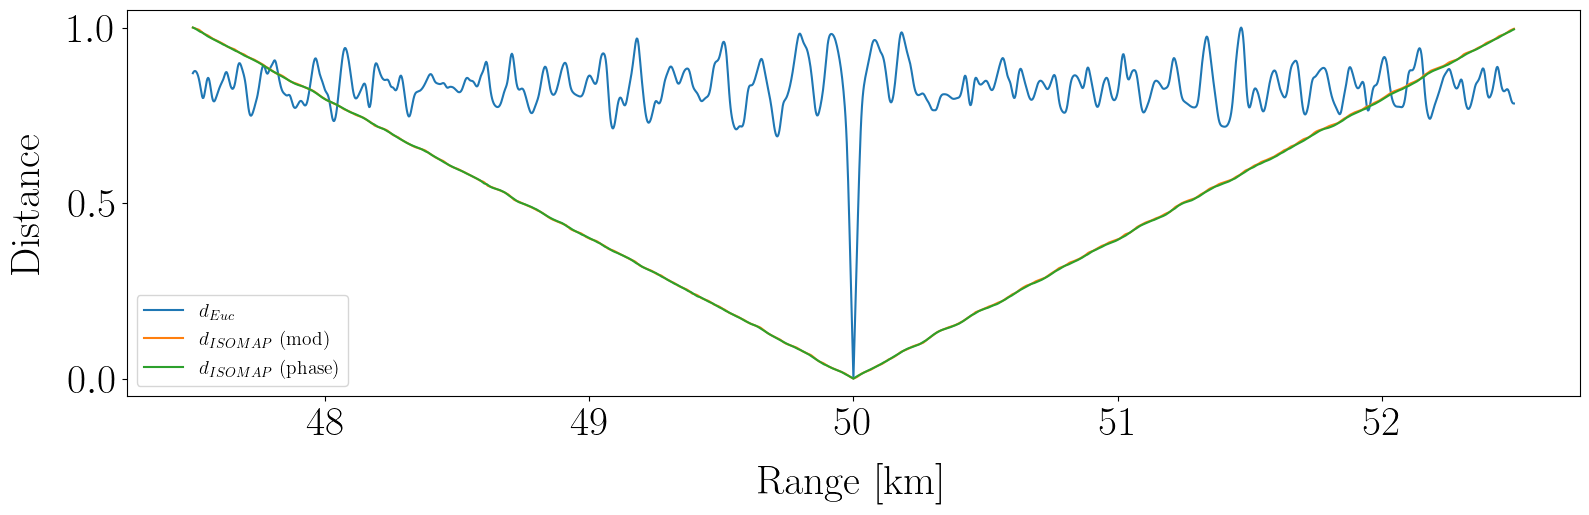

In [37]:
# Plot to compare
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Distance")

for key in X_isomap_dict.keys():
    d_isomap = X_isomap_dict[key]["d_isomap"]
    plt.plot(r_grid_km, d_isomap / np.max(d_isomap), label=r"$d_{ISOMAP}$" + f" ({key})")
plt.legend()

#### Commentaires


La méthode ne s'applique pas à des complexes, la réduction de dimension est donc appliquée successivement sur :

* La partie réelle des RTFs
* La partie imaginaire des RTFs
* Le module des RTFs
* La phase des RTFs

D'après le graphique ci-dessus, il est clair que l'information nécessaire à la localisation est contenue dans le module des RTFs. L'information de phase seule ne permet pas de localiser la source sans ambiguïté. 

Les résultats probants ci-dessus confirme l'existence d'une sous variété de dimension d = 1. La méthode ISOMAP permet d'apprendre efficacement la structure de cette espace non linéaire et de projeter les données sur un espace de dimension d = 1 représentatif de l'unique degré de liberté du problème. Dans cette représentation bien adaptée aux données, la distance euclidienne entre les données (les RTFs) et le point de référence (RTF pour la position de référence) évolue linéairement avec la distance à ce point. Une telle représentation permet d'estimer la position de la source sans ambiguïté. Cette position est donnée par l'unique minimum de la distance. 



### Diffusion distance


In [38]:
from pydiffmap import diffusion_map as dm

# initialize Diffusion map object.
neighbor_params = {"n_jobs": -1, "algorithm": "ball_tree"}

mydmap = dm.DiffusionMap.from_sklearn(
    n_evecs=d, k=5, epsilon="bgh", alpha=1.0, neighbor_params=neighbor_params
)
# fit to data and return the diffusion map.
X_diffmap = mydmap.fit_transform(X_augmented_mod)

print(mydmap.epsilon_fitted)

0.0009765625


In [39]:
X_diffmap_data = X_diffmap[:-1, :].T
X_diffmap_ref = X_diffmap[-1:, :].T

In [40]:
d_diffusion = np.linalg.norm(X_diffmap_data - X_diffmap_ref, axis=0)

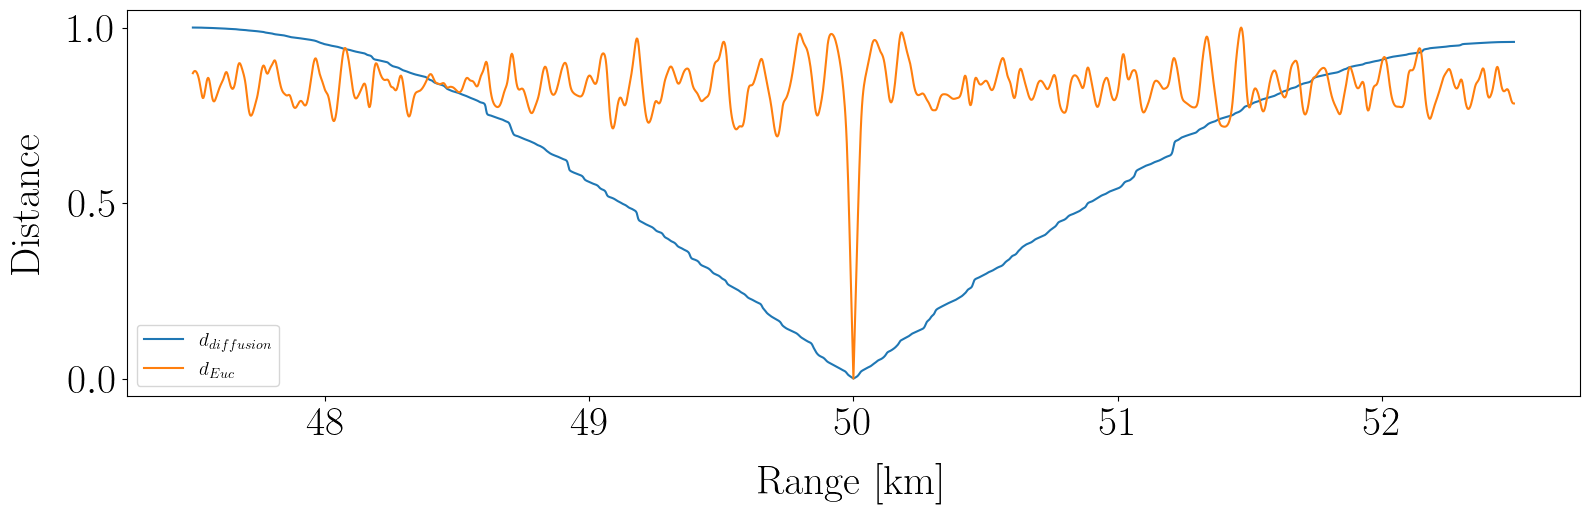

In [41]:
plt.figure()
plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{diffusion}$")
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.legend()

# plt.figure()
# plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{PCA}$")
# plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
# plt.xlabel("Range [km]")
# plt.ylabel("Distance")
# plt.xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
# plt.legend()

In [42]:
# from pydiffmap.visualization import embedding_plot, data_plot

# embedding_plot(mydmap, scatter_kwargs={"c": dmap[:, 0], "cmap": "Spectral"})
# data_plot(mydmap, dim=3, scatter_kwargs={"cmap": "Spectral"})

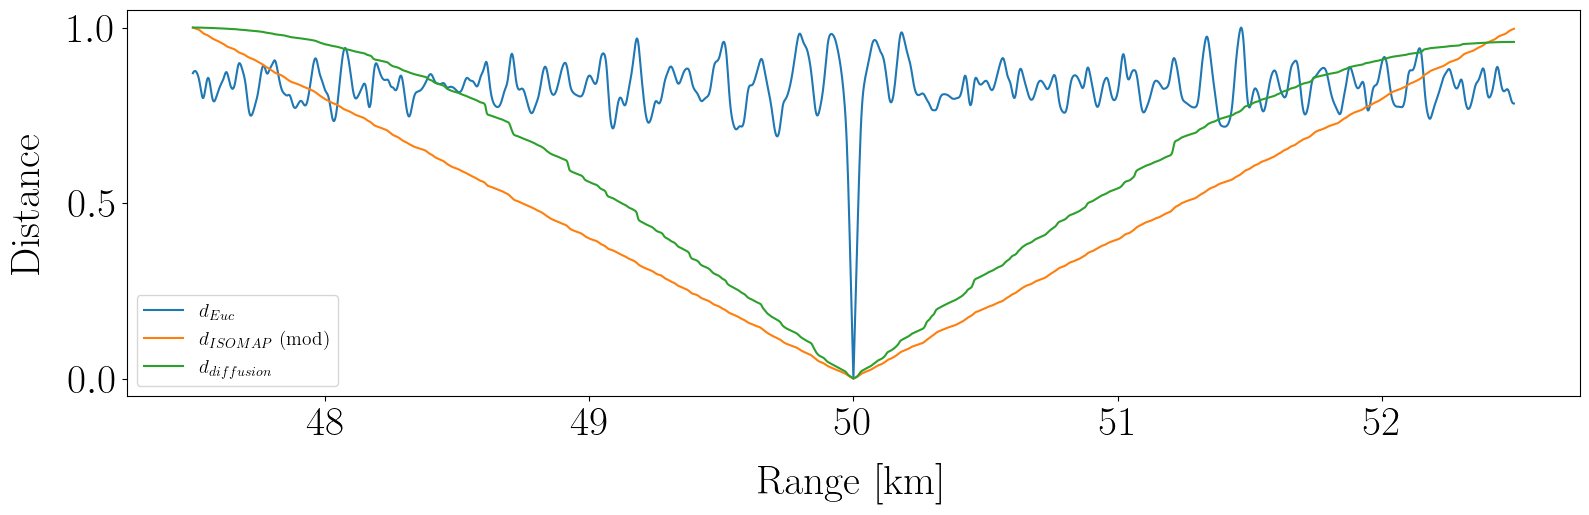

In [43]:
# Comparaison de toutes les distances
plt.figure()
plt.plot(r_grid_km, d_Euc / np.max(d_Euc), label=r"$d_{Euc}$")
# plt.plot(r_grid_km, d_PCA / np.max(d_PCA), label=r"$d_{PCA}$")
plt.plot(r_grid_km, X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]), label=r"$d_{ISOMAP}$ (mod)")
plt.plot(r_grid_km, d_diffusion / np.max(d_diffusion), label=r"$d_{diffusion}$")

plt.xlabel("Range [km]")
plt.ylabel("Distance")
plt.legend()

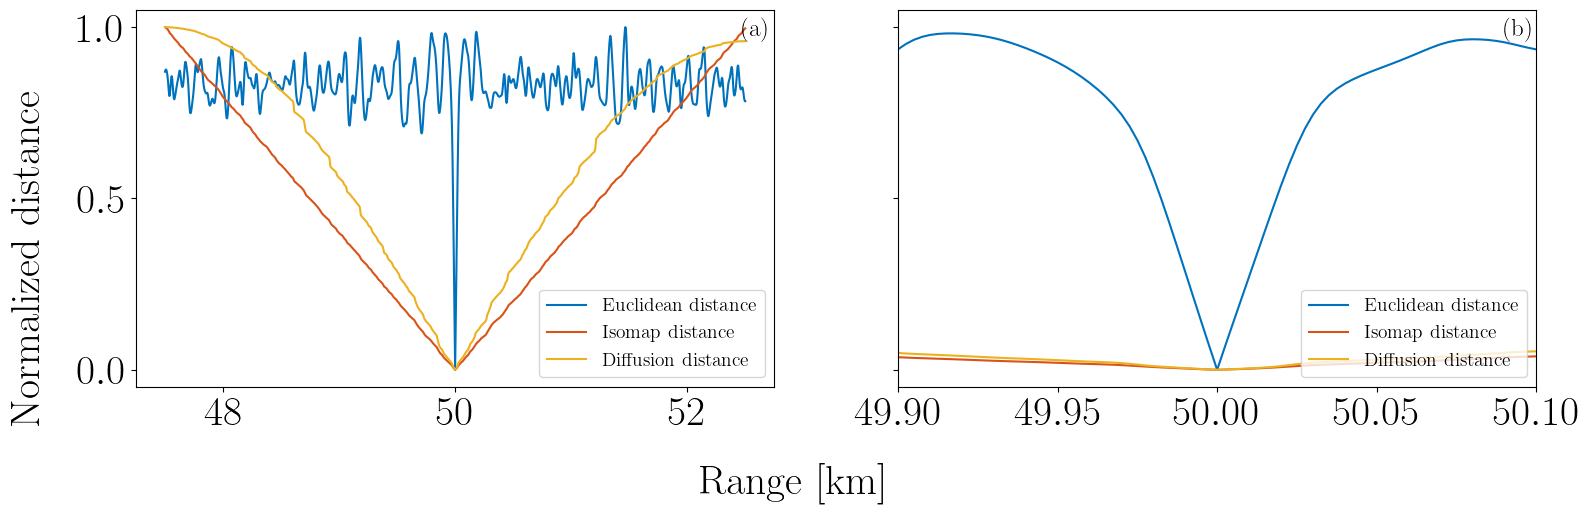

In [44]:
lfig = LargeFigure(legend_fontsize=14)
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)
ax1, ax2 = axs


ax1.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax1.plot(
    r_grid_km,
    X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]),
    color=color(1),
    label=f"Isomap distance",
)
ax1.plot(
    r_grid_km,
    d_diffusion / np.max(d_diffusion),
    color=color(2),
    label=f"Diffusion distance",
)
ax1.legend(loc="lower right")


ax2.plot(r_grid_km, d_Euc / np.max(d_Euc), color=color(0), label="Euclidean distance")
ax2.plot(
    r_grid_km,
    X_isomap_dict["mod"]["d_isomap"] / np.max(X_isomap_dict["mod"]["d_isomap"]),
    color=color(1),
    label=f"Isomap distance",
)
ax2.plot(
    r_grid_km,
    d_diffusion / np.max(d_diffusion),
    color=color(2),
    label=f"Diffusion distance",
)

ax2.set_xlim(r_ref / 1e3 - 0.1, r_ref / 1e3 + 0.1)
ax2.legend(loc="lower right")

fig.supxlabel("Range [km]")
fig.supylabel("Normalized distance")

# Add (a), (b) annatotation for subfigures
for i, ax in enumerate(axs):
    ax.text(
        0.95,
        0.98,
        f"({abcd_labels[i]})",
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="top",
    )

# Save figure
fname = f"dist_euclidean_isomap_diffusion_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

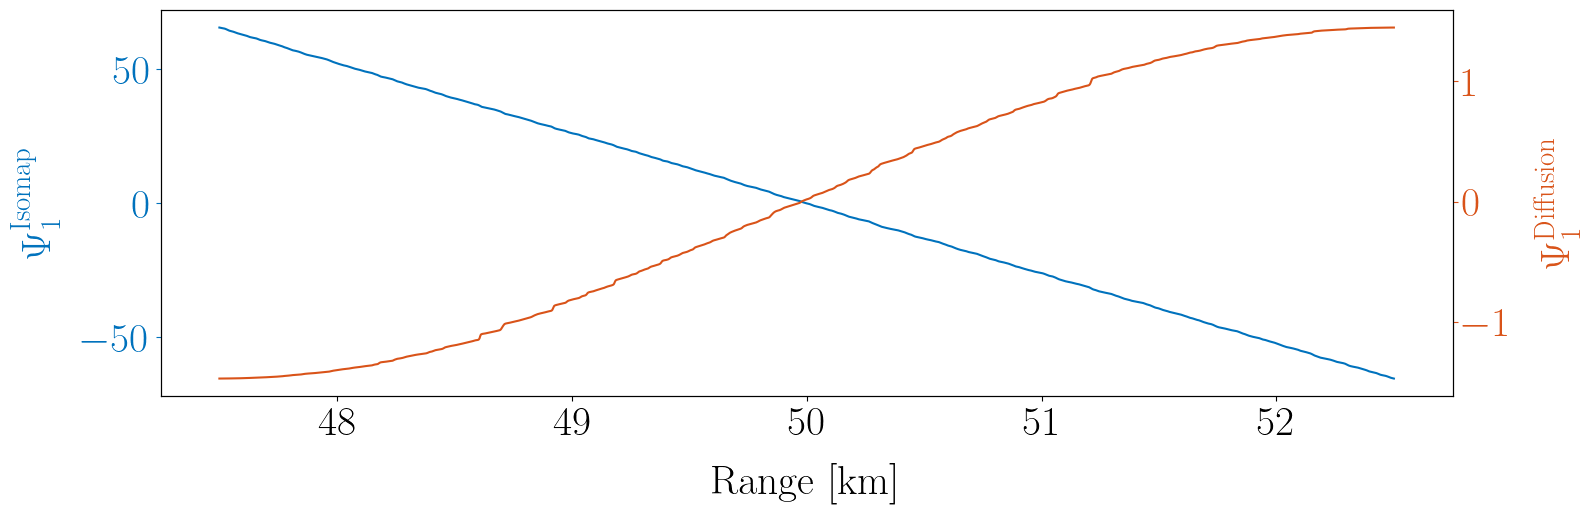

In [45]:
# Plot data in the diffusion embedding and isomap embedding
X_isomap = X_isomap_dict["mod"]["X_isomap"]
X_isomap_data = X_isomap[:-1, :].T

fig, ax = plt.subplots(1, 1)
ax.plot(r_grid_km, X_isomap_data[0, :], color=color(0))
ax.set_ylabel(r"$\Psi_1^{\text{Isomap}}$")

# Duplicate axis to plot diffusion embedding
ax2 = ax.twinx()
ax2.plot(r_grid_km, X_diffmap_data[0, :], color=color(1))
ax2.set_ylabel(r"$\Psi_1^{\text{Diffusion}}$")
ax.yaxis.label.set_color(color(0))
ax2.yaxis.label.set_color(color(1))
ax.tick_params(axis="y", colors=color(0))
ax2.tick_params(axis="y", colors=color(1))
ax.set_xlabel("Range [km]")

# Save figure
fname = f"embedding_isomap_diffusion_rmin{rmin*1e-3:.0f}_rmax{rmax*1e-3:.0f}_rref{r_ref*1e-3:.0f}_d12{d12}m_fmin{fmin}Hz_fmax{fmax}.png"
fpath = os.path.join(img_dir, fname)
plt.savefig(fpath, dpi=300)

## Cas d = 2

### Paramètres de la simulation

In [46]:
# # Waveguide
# # bottom_bc = 'pressure_release' # Bottom boundary condition
# bottom_bc = "perfectly_rigid"  # Bottom boundary condition
# Dw = 100 # Depth of the waveguide

# # Receiver
# d12 = 1000
# z_a = 50 # Depth of receiver

# # Source
# r_ref = 50 * 1e3 # Reference range in meters

# # Define depth vectors
# nzgrid = 100
# zmin = 1
# zmax = 15
# z_grid = np.linspace(zmin, zmax, nzgrid)

# # Define range vectors
# nrgrid = 200
# delta_r = 25 * 1e3
# rmin = r_ref - delta_r
# rmax = r_ref + delta_r
# r_grid = np.linspace(rmin, rmax, nrgrid)
# r_grid1 = r_grid    # Range from source to receiver 1
# r_grid2 = r_grid + d12  # Range from source to receiver 2

In [47]:
# # Frequency vector
# fmin = 5  # Minimum frequency in Hz
# fmax = 18  # Maximum frequency in Hz
# Df = 100  # Number of frequency samples
# f = np.linspace(fmin, fmax, Df) # Frequency vector

In [48]:
# # Compute RTF on the whole grid for a different number of modes
# ff, rr, zz, pi_12 = calc_pi_12(
#     f=f,
#     r_grid1=r_grid1,
#     r_grid2=r_grid2,
#     z_source=z_grid,
#     z_antenna=z_a,
#     depth=Dw,
#     bottom_bc=bottom_bc,
# )

# # Compute RTF at reference range
# ff, rr_ref, zz_ref, pi_12_ref = calc_pi_12(
#     f=f,
#     r_grid1=np.array([r_ref]),
#     r_grid2=np.array([r_ref + d12]),
#     z_source=z_s,
#     z_antenna=z_a,
#     depth=Dw,
#     bottom_bc=bottom_bc,
# )

# print("Dataset computed")

In [49]:
# ds = xr.Dataset(
#     data_vars=dict(
#         data=(
#             [
#                 "f",
#                 "z",
#                 "r",
#             ],
#             pi_12,
#         ),
#         data_ref=(["f"], pi_12_ref.squeeze()),
#     ),
#     coords=dict(
#         f=f,
#         r=rr[0, :],
#         z=zz[:, 0],
#     ),
#     attrs=dict(
#         description=f"RTF dataset for an ideal waveguide. The antenna is composed of two receivers separated by d12={d12}m. The antenna is at z_a={z_a}m in a waveguide of depth Dw={Dw}m.",
#         bottom_bc=bottom_bc,
#         Dw=Dw,
#         z_a=z_a,
#         z_ref=z_s,
#         r_ref=r_ref,
#         d12=d12,
#     ),
# )

In [50]:
# print(ds)

## Calcul de l'ensemble des distances 

### Distance Euclidienne 

In [51]:
# d_Euc = np.linalg.norm((ds.data - ds.data_ref.values[:, np.newaxis, np.newaxis]), axis=0)

In [52]:
# dist = d_Euc / np.max(d_Euc)
# dist += 1e-20
# dist = -10 * np.log10(dist)
# plt.figure()
# plt.pcolormesh(ds.r / 1e3, ds.z, dist, shading="auto", cmap="jet")
# plt.xlabel("Range [km]")
# plt.ylabel("Depth [m]")
# plt.colorbar(label="Normalized Euclidean distance [dB]")

### Angle hermitien

In [53]:
# inner_prod = np.abs(np.sum(ds.data_ref.values[:, np.newaxis, np.newaxis].conj() * ds.data, axis=0))
# norm_ref = np.linalg.norm(ds.data_ref, axis=0)
# norm_rtf = np.linalg.norm(ds.data, axis=0)
# # Cosine of Hermitian angle, clipped for stability
# cos_angle = np.clip(inner_prod / (norm_ref * norm_rtf), -1.0, 1.0)
# d_hermitien = np.arccos(cos_angle)


In [54]:
# dist = d_hermitien / np.max(d_hermitien)
# dist += 1e-20
# dist = -10 * np.log10(dist)
# plt.figure()
# plt.pcolormesh(ds.r / 1e3, ds.z, dist, shading="auto", cmap="jet")
# plt.xlabel("Range [km]")
# plt.ylabel("Depth [m]")
# plt.colorbar(label="Normalized Hermitian angle distance [dB]")